In [13]:
print(f"Minimum year in dataset: {df['YEAR'].min()}")
print(f"Maximum year in dataset: {df['YEAR'].max()}")
print(f"Unique years in dataset: {df['YEAR'].unique()}")

Minimum year in dataset: 1
Maximum year in dataset: 22
Unique years in dataset: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22]


In [35]:
# Filter data for years between 1 and 21 (corresponding to 2001 and 2021)
df_filtered_by_year = df[(df['YEAR'] >= 1) & (df['YEAR'] <= 21)]

# Calculate the mean of ACCDMG for the filtered data
mean_accdmg = df_filtered_by_year['ACCDMG'].mean()

# Round to 2 decimal places
mean_accdmg_rounded = round(mean_accdmg, 2)

print(f"The mean accident damage (ACCDMG) for accidents between 2001 and 2021 is: {mean_accdmg_rounded}")

The mean accident damage (ACCDMG) for accidents between 2001 and 2021 is: 716885.29


In [34]:
# Display the value counts for the FATALITY column
fatality_distribution = df['FATALITY'].value_counts()
print("Distribution of FATALITY variable:")
print(fatality_distribution)

# Calculate percentages for better interpretation
total_accidents = len(df)
fatality_percentage = (fatality_distribution / total_accidents) * 100
print("\nPercentage distribution of FATALITY variable:")
print(fatality_percentage)

# Evaluate the statements
num_fatality_1 = fatality_distribution.get(1, 0)
num_fatality_0 = fatality_distribution.get(0, 0)

print("\nEvaluation of statements:")

# Statement 1: The dataset contains roughly equal numbers of FATALITY = 0 and FATALITY = 1 accidents.
statement1_true = abs(num_fatality_0 - num_fatality_1) < (total_accidents * 0.2) # Roughly equal means within 20% of total for simplicity
print(f"The dataset contains roughly equal numbers of FATALITY = 0 and FATALITY = 1 accidents: {statement1_true}")

# Statement 2: Most accidents have FATALITY = 1, indicating fatalities or injuries are common.
statement2_true = num_fatality_1 > num_fatality_0
print(f"Most accidents have FATALITY = 1, indicating fatalities or injuries are common: {statement2_true}")

# Statement 3: Most accidents have FATALITY = 0, indicating that fatal or injury-related accidents are rare.
statement3_true = num_fatality_0 > num_fatality_1
print(f"Most accidents have FATALITY = 0, indicating that fatal or injury-related accidents are rare: {statement3_true}")

# Statement 4: The FATALITY column cannot be used because it contains many missing values.
statement4_true = df['FATALITY'].isnull().sum() > 0
print(f"The FATALITY column cannot be used because it contains many missing values: {statement4_true}")

Distribution of FATALITY variable:
FATALITY
0    6908
1     694
Name: count, dtype: int64

Percentage distribution of FATALITY variable:
FATALITY
0    90.870823
1     9.129177
Name: count, dtype: float64

Evaluation of statements:
The dataset contains roughly equal numbers of FATALITY = 0 and FATALITY = 1 accidents: False
Most accidents have FATALITY = 1, indicating fatalities or injuries are common: False
Most accidents have FATALITY = 0, indicating that fatal or injury-related accidents are rare: True
The FATALITY column cannot be used because it contains many missing values: False


In [33]:
# Create the 'FATALITY' column
df['FATALITY'] = ((df['TOTINJ'] + df['TOTKLD']) > 0).astype(int)

# Count the number of accidents where FATALITY = 1
fatality_count = df['FATALITY'].sum()

print(f"Number of accidents with FATALITY = 1: {fatality_count}")

Number of accidents with FATALITY = 1: 694


In [32]:
# Select the specified columns
selected_columns = ['ACCDMG', 'TRNSPD', 'TONS', 'TEMP', 'TYPE', 'CAUSE']
df_subset = df[selected_columns].copy()

# Get the number of rows before dropping nulls
rows_before_drop = len(df_subset)

# Drop rows with any null values in the subset
df_subset_cleaned = df_subset.dropna()

# Get the number of rows after dropping nulls
rows_after_drop = len(df_subset_cleaned)

# Calculate the number of dropped rows (each dropped row contained at least one null in the selected columns)
num_rows_dropped = rows_before_drop - rows_after_drop

print(f"Number of rows before dropping nulls: {rows_before_drop}")
print(f"Number of rows after dropping nulls: {rows_after_drop}")
print(f"Total number of rows dropped (due to nulls in specified columns): {num_rows_dropped}")

Number of rows before dropping nulls: 7602
Number of rows after dropping nulls: 7602
Total number of rows dropped (due to nulls in specified columns): 0


In [31]:
derailment_count = df[df['TYPE'] == 1].shape[0]
print(f"The number of accidents of type Derailment (TYPE 1) is: {derailment_count}")

The number of accidents of type Derailment (TYPE 1) is: 6117


In [30]:
derailed_count = word_frequencies['derailed']
print(f"The word 'derailed' occurs {derailed_count} times in the transformed NARR1 text.")

The word 'derailed' occurs 3232 times in the transformed NARR1 text.


In [27]:
# Install NLTK if not already installed
%pip install nltk

In [29]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import string
from collections import Counter

# Download necessary NLTK data (only needs to be done once)
nltk.download('punkt_tab') # Changed from 'punkt' to 'punkt_tab' as suggested by error
nltk.download('stopwords')

# Get English stop words
stop_words = set(stopwords.words('english'))

# Function to preprocess text
def preprocess_text(text):
    text = text.lower() # Convert to lowercase
    tokens = word_tokenize(text) # Tokenize
    # Remove punctuation and stop words
    processed_tokens = [word for word in tokens if word.isalpha() and word not in stop_words]
    return processed_tokens

# Apply preprocessing to NARR1 and flatten the list of lists
all_words = []
# Using narrative1_series from previous steps, which is already astype(str).fillna('')
for narrative in narrative1_series:
    all_words.extend(preprocess_text(narrative))

# Calculate word frequencies
word_frequencies = Counter(all_words)

# Get the 20 most frequent words
top_20_frequent_words = [word for word, count in word_frequencies.most_common(20)]

print(f"Top 20 most frequent words: {top_20_frequent_words}")

# Check for the specified terms
terms_to_check = ['mph', 'derailed', 'north', 'traveling', 'crew']
present_terms = [term for term in terms_to_check if term in top_20_frequent_words]

if present_terms:
    print(f"\nThe following terms are in the 20 most frequent words: {', '.join(present_terms)}")
else:
    print("\nNone of the specified terms are in the 20 most frequent words.")

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Top 20 most frequent words: ['train', 'derailed', 'cars', 'track', 'main', 'due', 'traveling', 'car', 'crew', 'pulling', 'yard', 'rail', 'broken', 'east', 'mp', 'emergency', 'went', 'lead', 'west', 'railcars']

The following terms are in the 20 most frequent words: derailed, traveling, crew


In [26]:
# Get the number of narratives (rows) in the DataFrame
num_narratives = len(df)

# Calculate the average number of words
average_words_narr1 = total_words_narr1 / num_narratives

# Round to the nearest whole number
average_words_narr1_rounded = round(average_words_narr1)

print(f"The average number of words in the NARR1 variable is: {average_words_narr1_rounded}")

The average number of words in the NARR1 variable is: 17


In [25]:
# Convert NARR1 to string type to handle mixed types and potential non-string entries gracefully
# Then fill any NaN values with an empty string to avoid errors during word splitting
narrative1_series = df['NARR1'].astype(str).fillna('')

# Define a function to count words in a string
def count_words(text):
    return len(text.split())

# Apply the function to the NARR1 series and sum the results
total_words_narr1 = narrative1_series.apply(count_words).sum()

print(f"The total number of words in the NARR1 variable is: {total_words_narr1}")

The total number of words in the NARR1 variable is: 126450


In [24]:
missing_trkdnsty = df['TRKDNSTY'].isnull().sum()
print(f"Number of missing values in TRKDNSTY: {missing_trkdnsty}")

Number of missing values in TRKDNSTY: 2311


In [23]:
# Find the maximum value in TOTINJ
max_totinj = df['TOTINJ'].max()

# Filter the DataFrame to get the accident(s) with the maximum TOTINJ
highest_injuries_accidents = df[df['TOTINJ'] == max_totinj]

# Display relevant columns for these accidents
print("Accident(s) with the highest total injuries:")
for index, row in highest_injuries_accidents.iterrows():
    print(f"- ACCDMG: {row['ACCDMG']:.2f}")
    print(f"- TYPE: {row['TYPE']}")
    print(f"- WEATHER: {row['WEATHER']}")
    print(f"- CAUSE: {row['CAUSE']}")

# Evaluate the statements

# Statement 1: The accident occurred in foggy weather (WEATHER 4)
foggy_weather = False
if 4 in highest_injuries_accidents['WEATHER'].values:
    foggy_weather = True

# Statement 2: The accident cost (ACCDMG) is less than $2 million
less_than_2M = True
for accdmg in highest_injuries_accidents['ACCDMG']:
    if accdmg >= 2000000:
        less_than_2M = False
        break

# Statement 3: The accident is of TYPE Derailment (TYPE 1)
is_derailment = False
if 1 in highest_injuries_accidents['TYPE'].values:
    is_derailment = True

# Statement 4: The accident CAUSE is Human Factors (the cause code starts with an H)
is_human_factors = False
for cause in highest_injuries_accidents['CAUSE']:
    if isinstance(cause, str) and cause.startswith('H'):
        is_human_factors = True
        break

print("\nEvaluation of statements:")
print(f"The accident occurred in foggy weather (WEATHER 4): {foggy_weather}")
print(f"The accident cost (ACCDMG) is less than $2 million: {less_than_2M}")
print(f"The accident is of TYPE Derailment (TYPE 1): {is_derailment}")
print(f"The accident CAUSE is Human Factors (the cause code starts with an H): {is_human_factors}")

Accident(s) with the highest total injuries:
- ACCDMG: 1327730.00
- TYPE: 1
- WEATHER: 2
- CAUSE: T215

Evaluation of statements:
The accident occurred in foggy weather (WEATHER 4): False
The accident cost (ACCDMG) is less than $2 million: True
The accident is of TYPE Derailment (TYPE 1): True
The accident CAUSE is Human Factors (the cause code starts with an H): False


In [22]:
# Group by IMO and sum TOTINJ
total_injuries_by_month = df.groupby('IMO')['TOTINJ'].sum()

# Find the month with the highest total injuries
highest_injuries_month = total_injuries_by_month.idxmax()

print(f"The incident month (IMO) with the highest number of total injuries is: {highest_injuries_month}")

The incident month (IMO) with the highest number of total injuries is: 1


In [21]:
overall_mean_trnspd = df['TRNSPD'].mean()
print(f"The overall mean TRNSPD in the dataset is: {overall_mean_trnspd:.2f}")

mean_trnspd_type1 = 19.90 # From previous calculation

if mean_trnspd_type1 < overall_mean_trnspd:
    print("The mean TRNSPD for accidents of TYPE 1 (Derailment) is significantly lower than the overall mean.")
elif mean_trnspd_type1 > overall_mean_trnspd:
    print("The mean TRNSPD for accidents of TYPE 1 (Derailment) is higher than the overall mean.")
else:
    print("The mean TRNSPD for accidents of TYPE 1 (Derailment) is about the same as the overall mean.")

The overall mean TRNSPD in the dataset is: 20.13
The mean TRNSPD for accidents of TYPE 1 (Derailment) is significantly lower than the overall mean.


In [19]:
print(df['TYPE'].value_counts())
print(df['TYPE'].unique())

TYPE
1     6117
7      369
12     236
4      235
11     132
13     125
3      121
9      112
2       73
5       51
6       17
8       12
10       2
Name: count, dtype: int64
[ 1  9  4 13  7  3 12 11  2 10  5  6  8]


In [20]:
mean_trnspd_type1 = df[df['TYPE'] == 1]['TRNSPD'].mean()
print(f"The mean TRNSPD for accidents of TYPE 1 (Derailment) is: {mean_trnspd_type1:.2f}")

The mean TRNSPD for accidents of TYPE 1 (Derailment) is: 19.90


In [17]:
# Group by IYR and IMO and sum ACCDMG
total_damage_by_month_year = df.groupby(['IYR', 'IMO'])['ACCDMG'].sum()

# Find the month-year combination with the highest total damage
max_damage_combination = total_damage_by_month_year.idxmax()

# Extract IYR and IMO
highest_damage_iyr = max_damage_combination[0]
highest_damage_imo = max_damage_combination[1]

print(f"The month-year combination with the highest total accident damage is:")
print(f"IYR: {highest_damage_iyr}")
print(f"IMO: {highest_damage_imo}")

The month-year combination with the highest total accident damage is:
IYR: 15
IMO: 5


In [16]:
print(df['CARSHZD'].value_counts())
print(df['CARSHZD'].describe())
print(df['CARSHZD'].dtype)

CARSHZD
0     7297
1      179
2       53
3       25
4       12
5       11
7        8
6        3
20       2
10       2
9        2
15       1
11       1
12       1
32       1
26       1
18       1
14       1
8        1
Name: count, dtype: int64
count    7602.000000
mean        0.098790
std         0.846362
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        32.000000
Name: CARSHZD, dtype: float64
int64


In [15]:
most_common_imo = df['IMO'].mode()[0]
print(f"The most common accident month (IMO) in the dataset is: {most_common_imo}")

The most common accident month (IMO) in the dataset is: 7


/tmp/ipython-input-3071907907.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='TYPE', y='ACCDMG', data=df, palette='viridis')


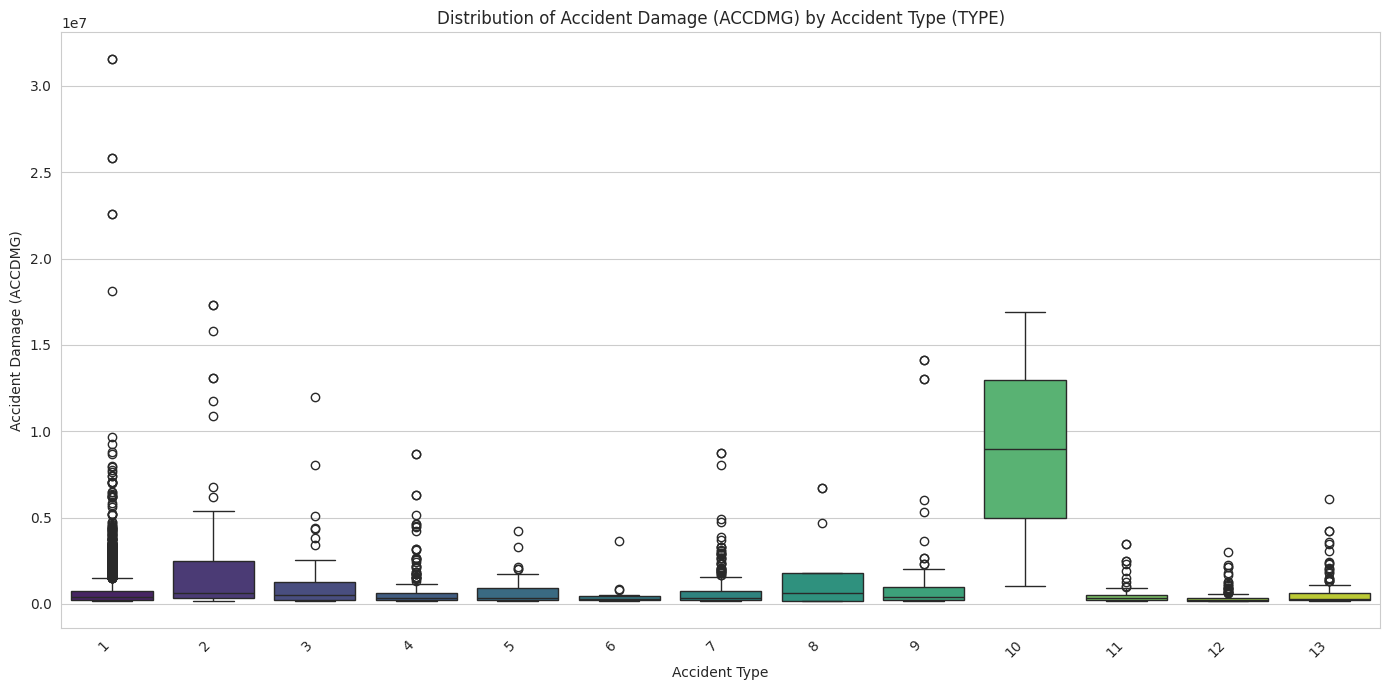

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 7))
sns.boxplot(x='TYPE', y='ACCDMG', data=df, palette='viridis')
plt.title('Distribution of Accident Damage (ACCDMG) by Accident Type (TYPE)')
plt.xlabel('Accident Type')
plt.ylabel('Accident Damage (ACCDMG)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

/tmp/ipython-input-1774852013.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='TYPE', y='TRNSPD', data=df, palette='Set3')


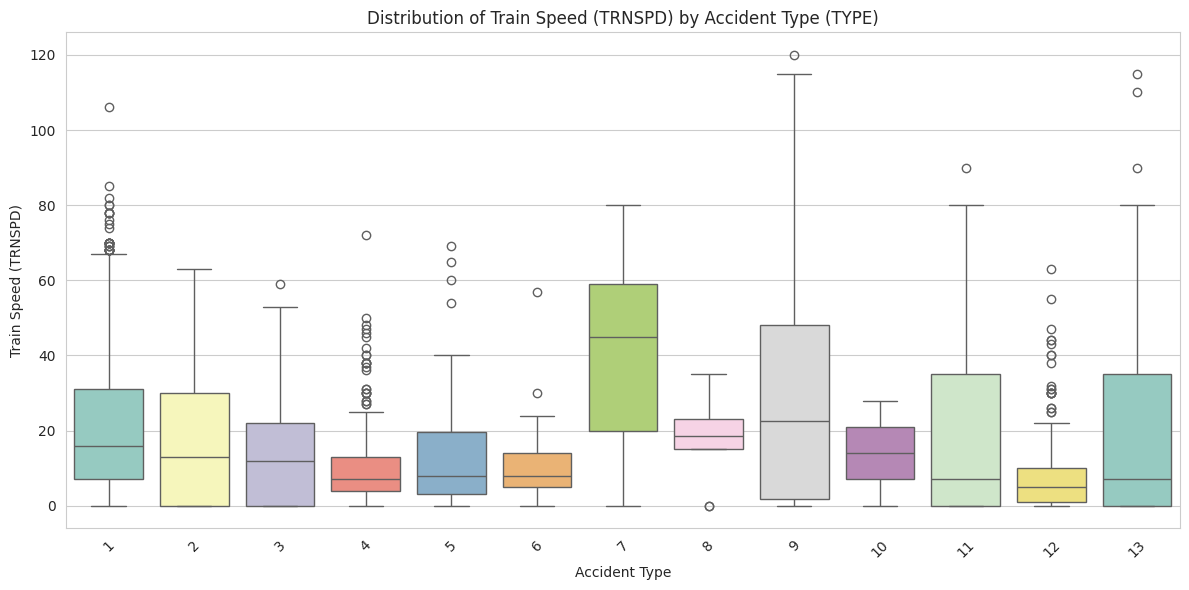

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.boxplot(x='TYPE', y='TRNSPD', data=df, palette='Set3')
plt.title('Distribution of Train Speed (TRNSPD) by Accident Type (TYPE)')
plt.xlabel('Accident Type')
plt.ylabel('Train Speed (TRNSPD)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/tmp/ipython-input-1380374017.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='REGION', y='ACCDMG', data=df, errorbar=None, palette='viridis')
/tmp/ipython-input-1380374017.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='REGION', y='ACCDMG', data=df, palette='viridis')


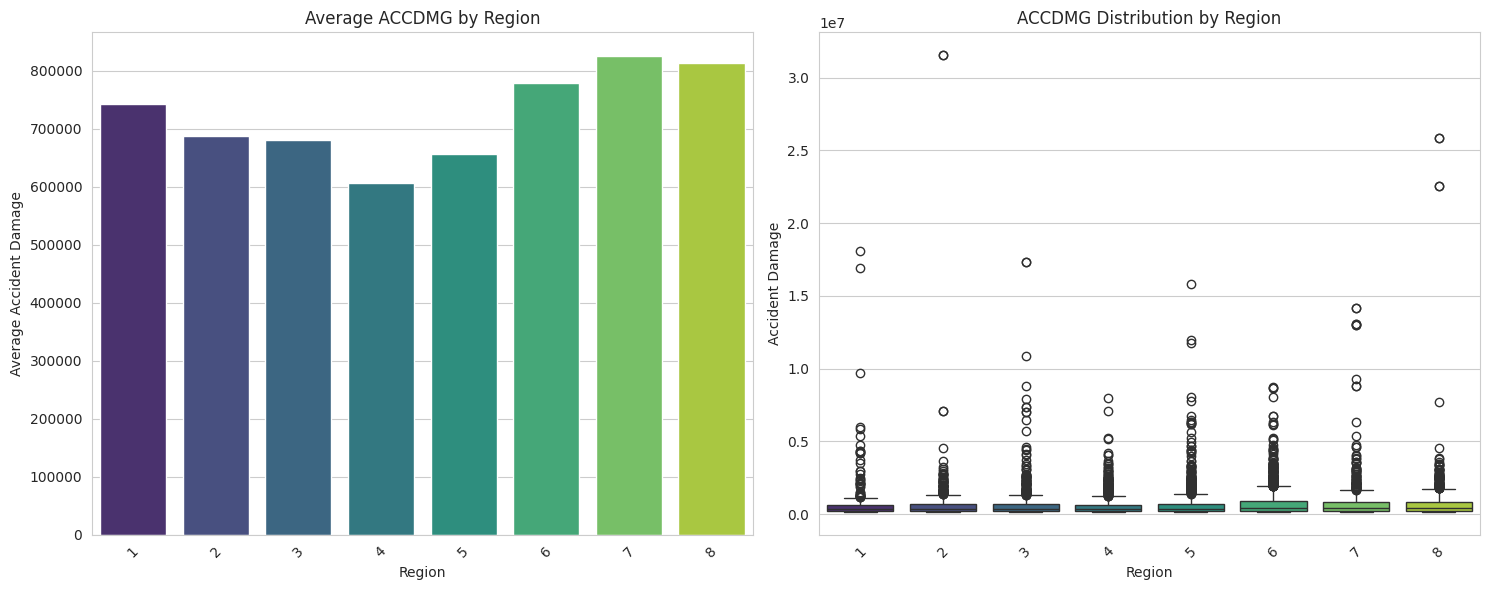

/tmp/ipython-input-1380374017.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='REGION', y='TOTINJ', data=df, errorbar=None, palette='plasma')
/tmp/ipython-input-1380374017.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='REGION', y='TOTINJ', data=df, palette='plasma')


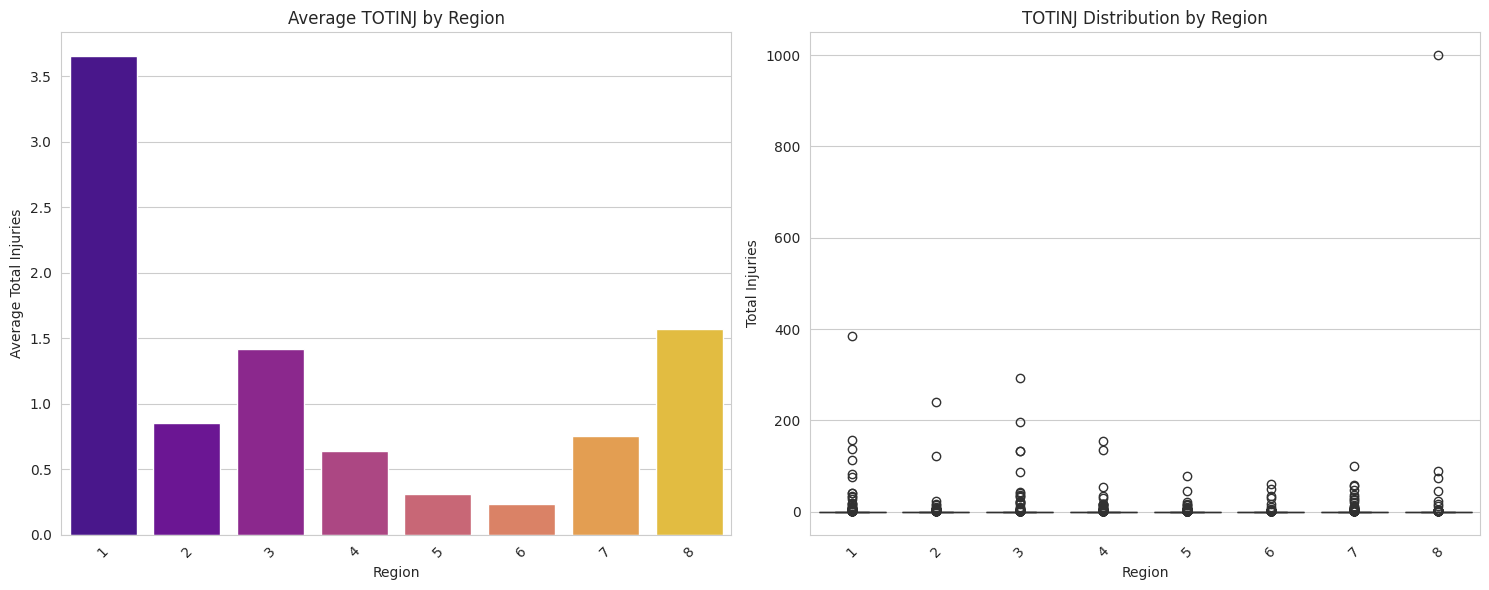

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the aesthetic style of the plots
sns.set_style("whitegrid")

# Create subplots for ACCDMG
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1) # Barplot for ACCDMG by REGION
sns.barplot(x='REGION', y='ACCDMG', data=df, errorbar=None, palette='viridis')
plt.title('Average ACCDMG by Region')
plt.xlabel('Region')
plt.ylabel('Average Accident Damage')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2) # Boxplot for ACCDMG by REGION
sns.boxplot(x='REGION', y='ACCDMG', data=df, palette='viridis')
plt.title('ACCDMG Distribution by Region')
plt.xlabel('Region')
plt.ylabel('Accident Damage')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Create subplots for TOTINJ
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1) # Barplot for TOTINJ by REGION
sns.barplot(x='REGION', y='TOTINJ', data=df, errorbar=None, palette='plasma')
plt.title('Average TOTINJ by Region')
plt.xlabel('Region')
plt.ylabel('Average Total Injuries')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2) # Boxplot for TOTINJ by REGION
sns.boxplot(x='REGION', y='TOTINJ', data=df, palette='plasma')
plt.title('TOTINJ Distribution by Region')
plt.xlabel('Region')
plt.ylabel('Total Injuries')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

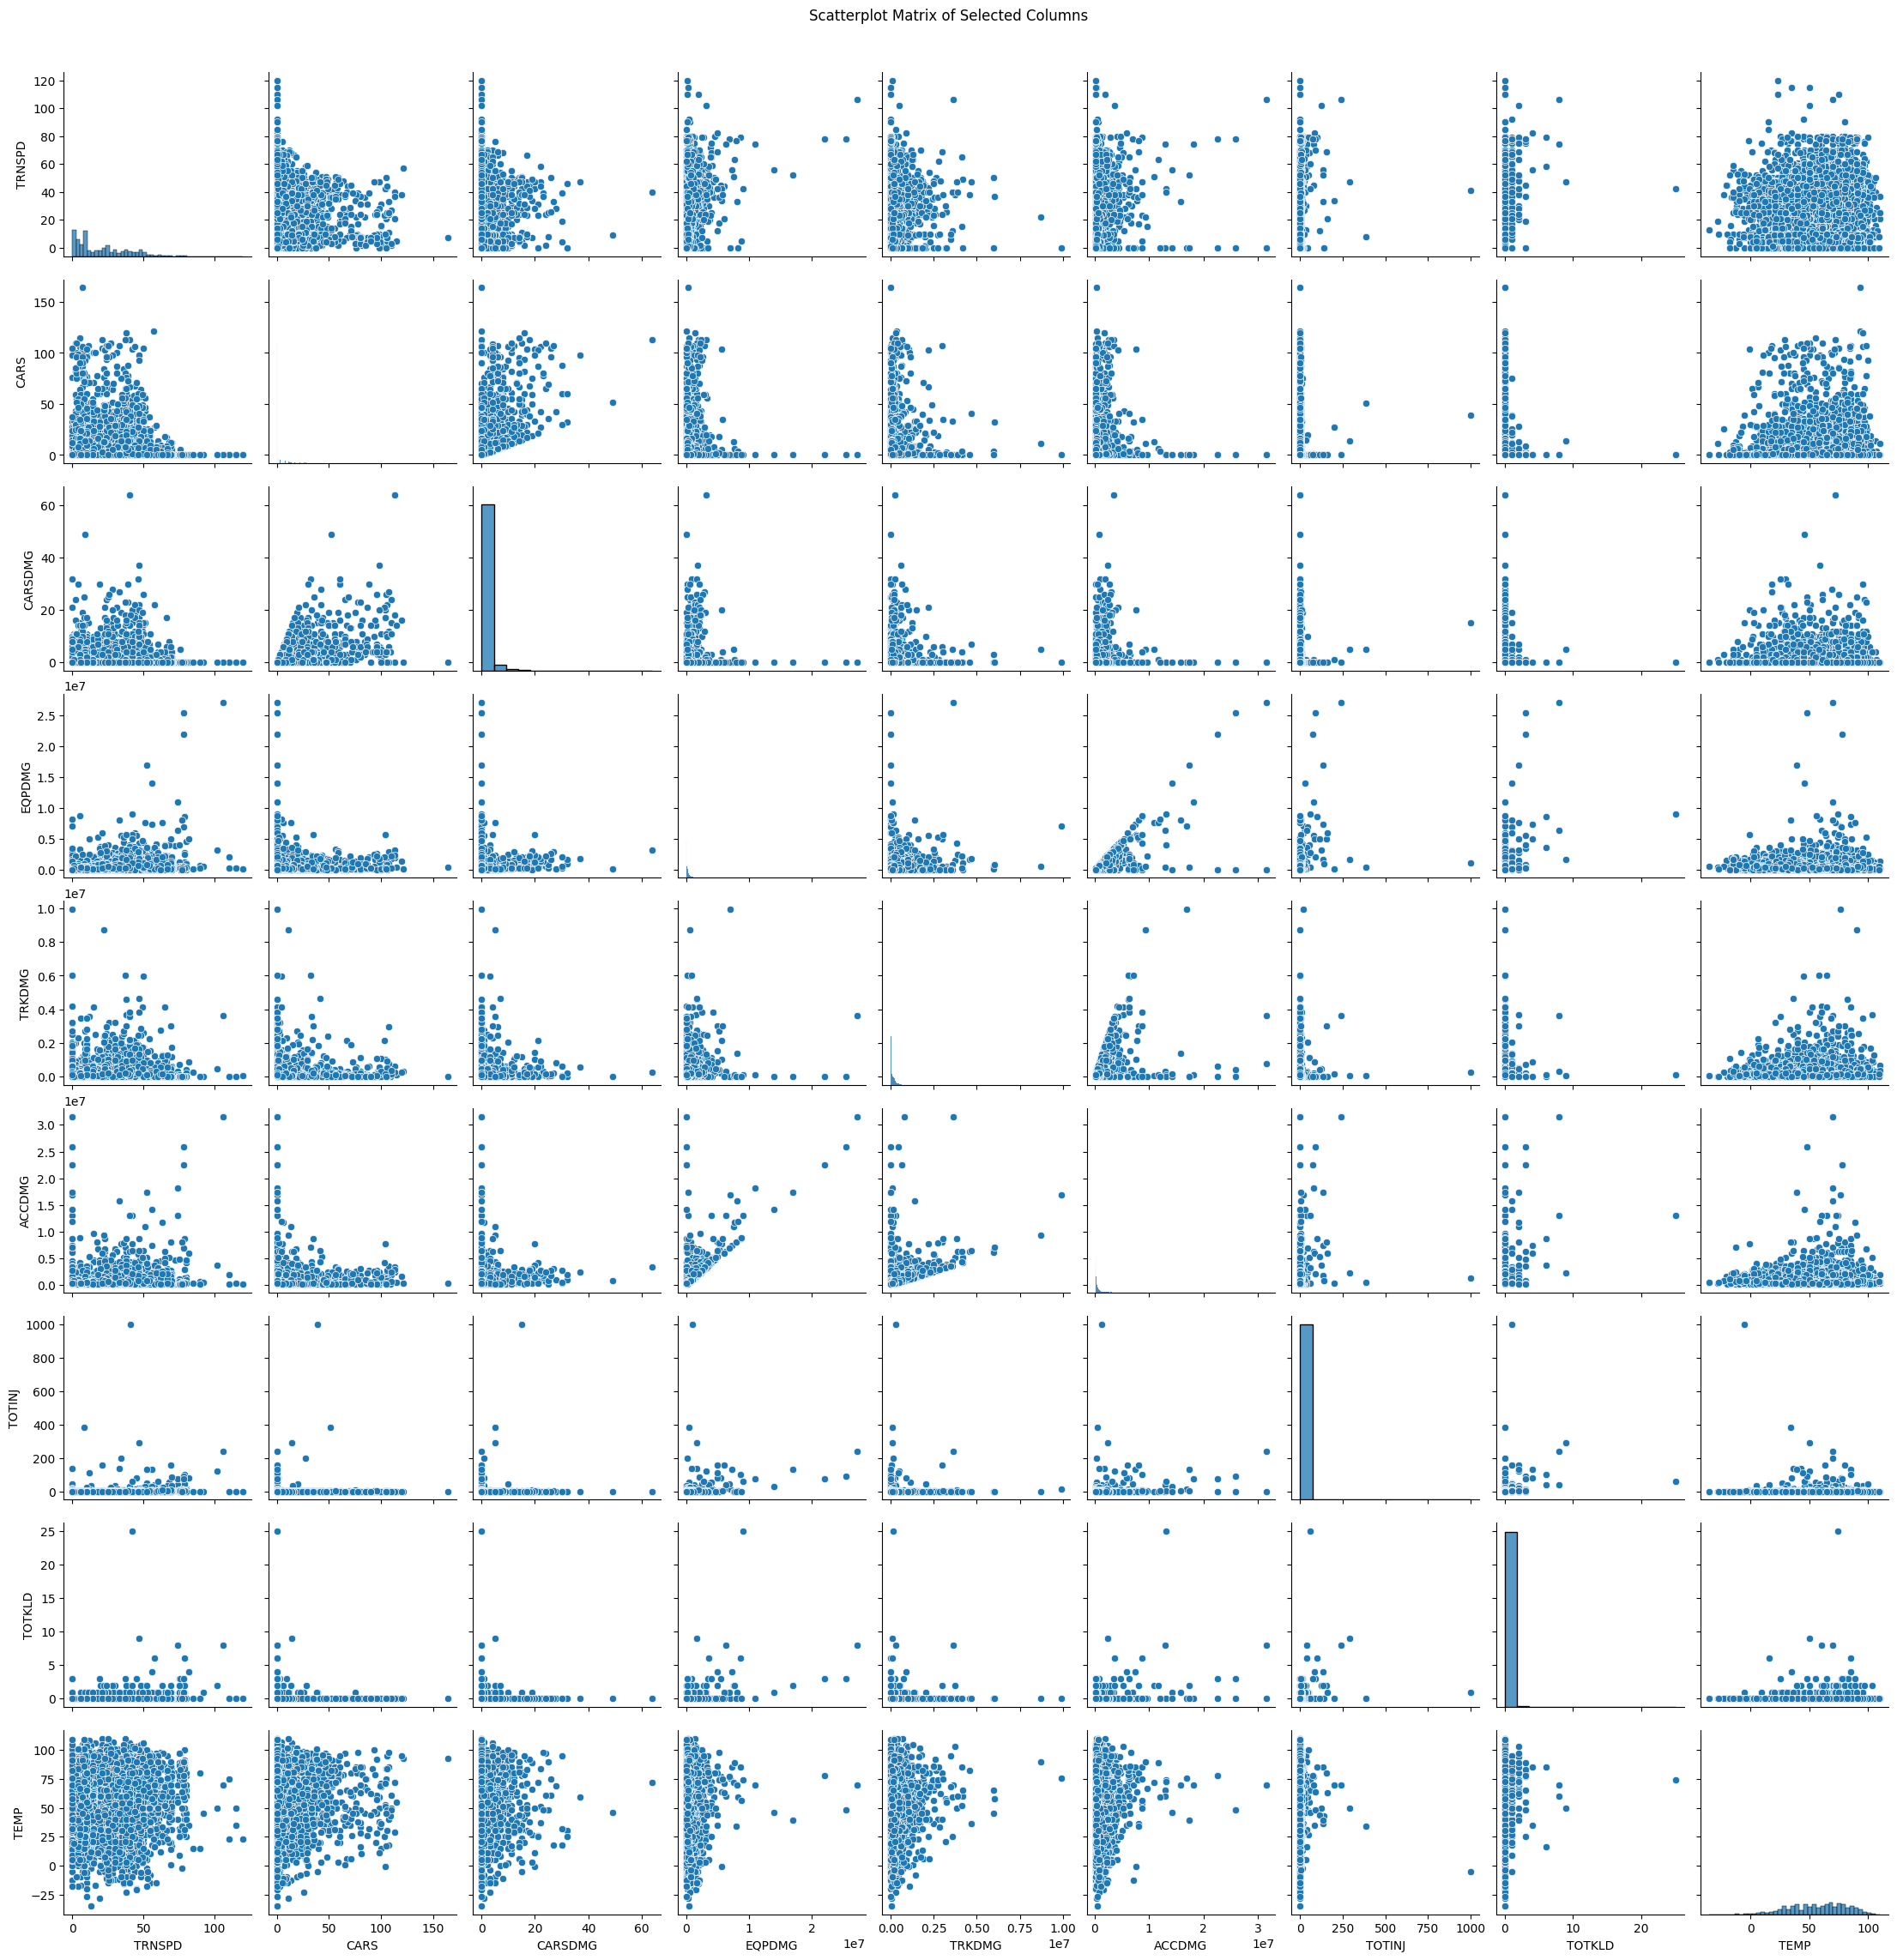

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming df_subset contains the desired columns for the scatterplot matrix
# If not, you might need to redefine df_subset or use the full DataFrame

# Generate the scatterplot matrix
sns.pairplot(df_subset)
plt.suptitle('Scatterplot Matrix of Selected Columns', y=1.02) # Adjust suptitle position
plt.show()

In [7]:
temp_correlations = correlation_matrix['TEMP'].drop('TEMP')
high_corr_with_temp = temp_correlations[temp_correlations.abs() > 0.5]

if not high_corr_with_temp.empty:
    print("Variables with an absolute correlation greater than 0.5 with 'TEMP':")
    for index, value in high_corr_with_temp.items():
        print(f"- {index}: {value:.2f}")
else:
    print("No variables found with an absolute correlation greater than 0.5 with 'TEMP'.")

No variables found with an absolute correlation greater than 0.5 with 'TEMP'.


In [6]:
correlation_trkdmg_accdmg = correlation_matrix.loc['TRKDMG', 'ACCDMG']
correlation_trkdmg_eqpdmg = correlation_matrix.loc['TRKDMG', 'EQPDMG']

print(f"The correlation between 'TRKDMG' and 'ACCDMG' is: {correlation_trkdmg_accdmg:.2f}")
print(f"The correlation between 'TRKDMG' and 'EQPDMG' is: {correlation_trkdmg_eqpdmg:.2f}")

The correlation between 'TRKDMG' and 'ACCDMG' is: 0.42
The correlation between 'TRKDMG' and 'EQPDMG' is: 0.18


In [5]:
correlation_totinj_totkld = correlation_matrix.loc['TOTINJ', 'TOTKLD']
print(f"The correlation between 'TOTINJ' and 'TOTKLD' is: {correlation_totinj_totkld:.2f}")

The correlation between 'TOTINJ' and 'TOTKLD' is: 0.26


In [4]:
# Make a copy of the correlation matrix and set diagonal to 0 to exclude self-correlations
corr_no_self = correlation_matrix.copy()
for i in range(corr_no_self.shape[0]):
    corr_no_self.iloc[i, i] = 0

# Find the maximum absolute correlation value
max_corr_value = corr_no_self.abs().max().max()

# Find the indices (row and column) of this maximum value
# Use .unstack() to convert the correlation matrix into a Series and find the index of the max value
max_corr_series = corr_no_self.unstack()
strongest_pair = max_corr_series.abs().idxmax()

# Get the actual correlation value for the strongest pair
strongest_correlation = corr_no_self.loc[strongest_pair[0], strongest_pair[1]]

print(f"The strongest correlation is between '{strongest_pair[0]}' and '{strongest_pair[1]}' with a value of {strongest_correlation:.2f}.")

The strongest correlation is between 'EQPDMG' and 'ACCDMG' with a value of 0.76.


In [3]:
# Initialize a counter for pairs with correlation > 0.6
count = 0

# Iterate through the correlation matrix
# We iterate only the upper triangle (excluding the diagonal) to avoid duplicate pairs and self-correlation
for i in range(correlation_matrix.shape[0]):
    for j in range(i + 1, correlation_matrix.shape[1]):
        if abs(correlation_matrix.iloc[i, j]) > 0.6:
            count += 1

print(f"Number of pairs with an absolute correlation greater than 0.6: {count}")

Number of pairs with an absolute correlation greater than 0.6: 1


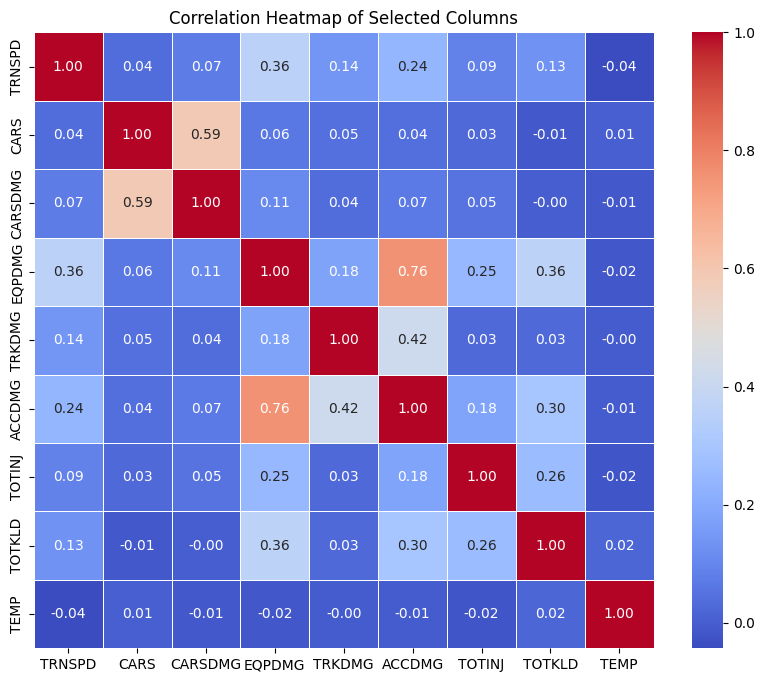

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select the specified columns
columns_for_heatmap = ['TRNSPD', 'CARS', 'CARSDMG', 'EQPDMG', 'TRKDMG', 'ACCDMG', 'TOTINJ', 'TOTKLD', 'TEMP']
df_subset = df[columns_for_heatmap]

# Calculate the correlation matrix
correlation_matrix = df_subset.corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Selected Columns')
plt.show()

In [1]:
import pandas as pd

df = pd.read_csv('/content/xdmgnd.csv')
display(df.head())

/tmp/ipython-input-2545995493.py:3: DtypeWarning: Columns (100,121) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/xdmgnd.csv')


,Unnamed: 0,IYR,IMO,RAILROAD,INCDTNO,IYR2,IMO2,RR2,INCDTNO2,IYR3,...,Longitud,SIGNAL,MOPERA,ADJUNCT1,ADJUNCT2,ADJUNCT3,SUBDIV,Type,Typeq,Cause
0,1,1,3,ATK,067106,NaN,NaN,NaN,NaN,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Derailment,Passenger,T
1,2,1,3,BNSF,MT0301100,NaN,NaN,NaN,NaN,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Derailment,Freight,E
2,3,1,3,BNSF,MT0301103,NaN,NaN,NaN,NaN,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Derailment,Freight,H
3,4,1,1,BNSF,AO0101104,NaN,NaN,NaN,NaN,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Derailment,Freight,M
4,5,1,1,BNSF,DK0101112,NaN,NaN,NaN,NaN,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Derailment,Freight,E
